In [29]:
import sys
sys.path.append('../src')

In [30]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandContext, TriangleIntegrandEvaluator, spherical
from plot_util import plot_complex_integration_with_ref
from wrapped_eval import WrappedEvaluator
from integrand_builder import IntegrandBuilder
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from symbolica import RandomNumberGenerator

# do this to trigger the banner here so it doesn't get in the way later
import oneloop_bridge
oneloop_bridge.set_renormalization_scale(1.0)

In [31]:
ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.center_counterterm_region_at_origin = False
ib.check_singularities_per_sample = False # not necessary for this example
ib.smooth_mask = True
tie = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "combined_result"), ctx
)

Compiling evaluator: "combined_result"
Done!


# plot the integrand and threshold subtraction

In [32]:
from context_manager import norm

ctx.set_external_momenta(1, 3, 8)

qs, _ = ctx.get_ordered_qs_and_masses()

threshold_masses = [norm((qs[i]-qs[j])/2)**0.5 for (i,j) in [(0,1), (1,2), (0,2)]]
print(threshold_masses)

[np.float64(0.8660254037844386), np.float64(0.5), np.float64(1.414213562373095)]


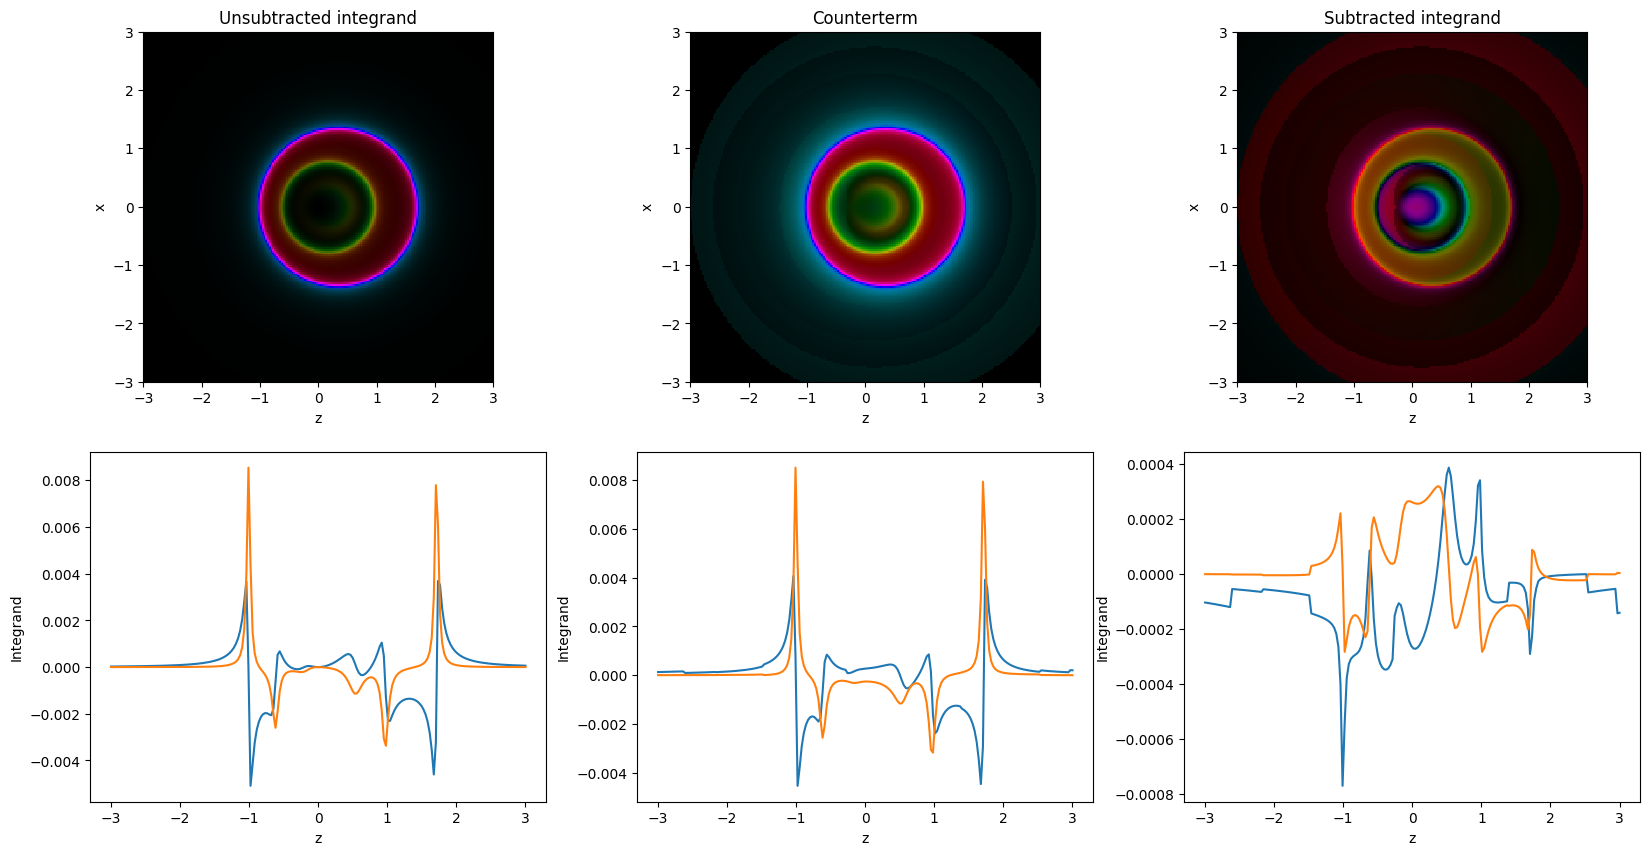

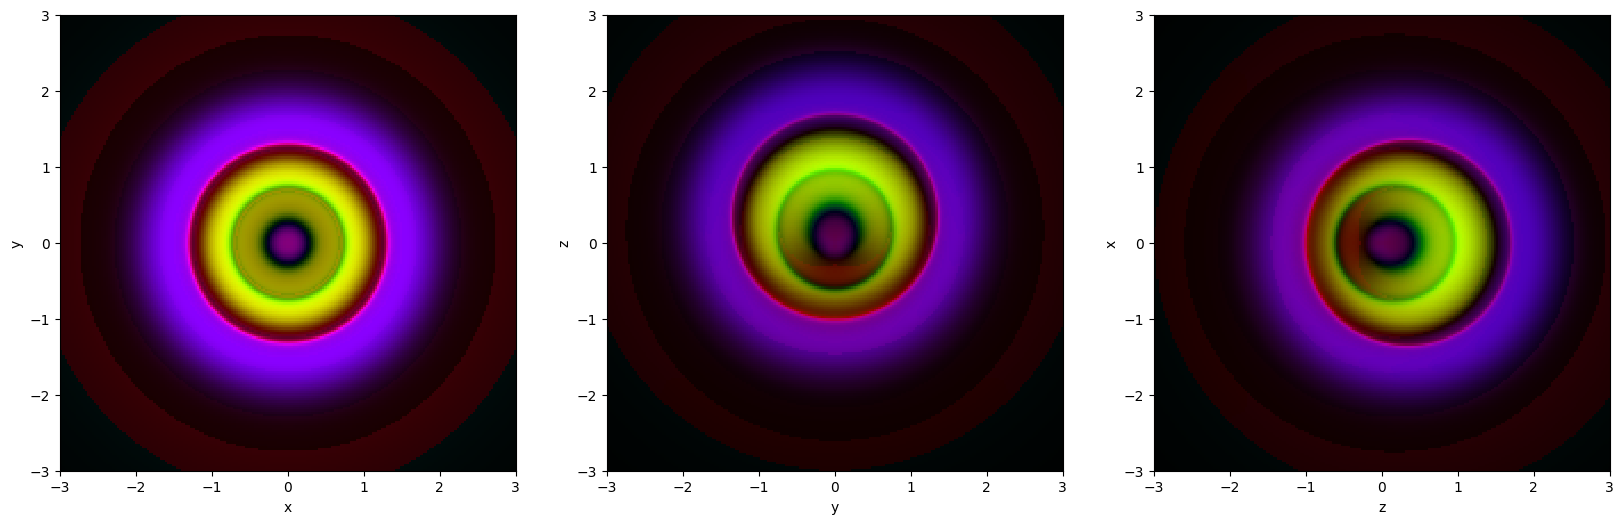

In [33]:
mass = 0.4-0.1j
ctx.masses = [mass, mass, mass]
ctx.threshold = 2
ctx.mask_width = 0.5
ctx.max_eta_min = 1e20
tie.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.show()

ctx.combined_integrand()
tie.plot_planes((-3,3),(-3,3), divide_jacobian = True,res = 200)
plt.show()

In [34]:
rng = RandomNumberGenerator(0,0)

In [35]:
def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [36]:
mass = 0.4
sample_masses = mass - 0.08j*0.0001**np.linspace(0,1,15)
ref_masses = mass - 0.08j*0.0001**np.linspace(0,1,50)

ctx.combined_integrand()
global_check_res = integrate_over_masses(sample_masses, tie, epochs = 100, steps = 500)

ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

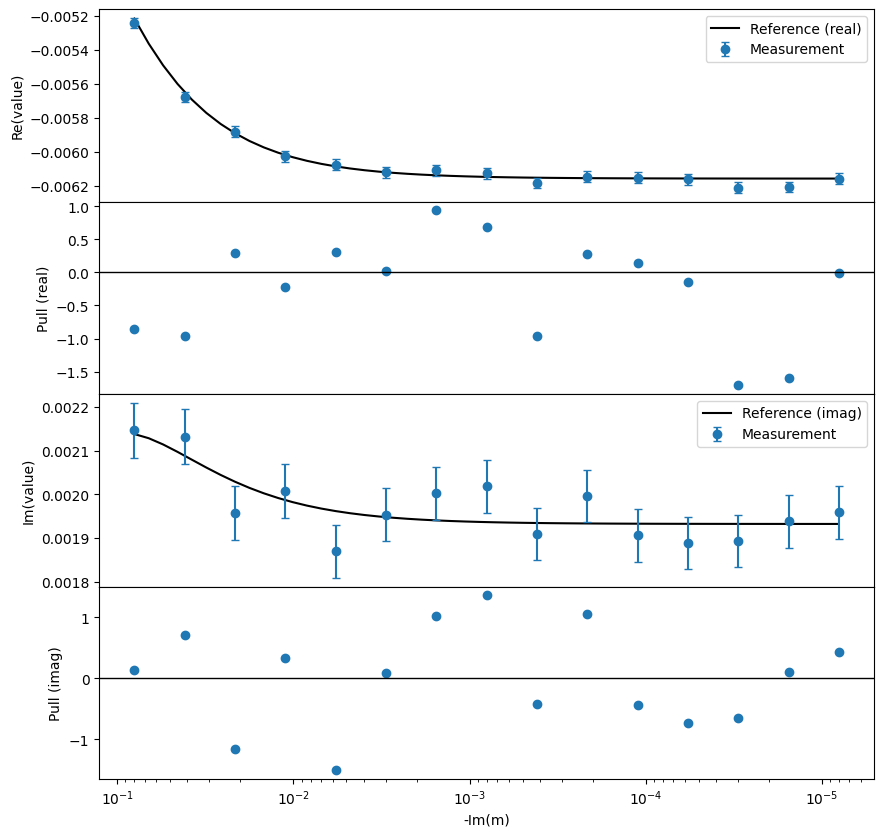

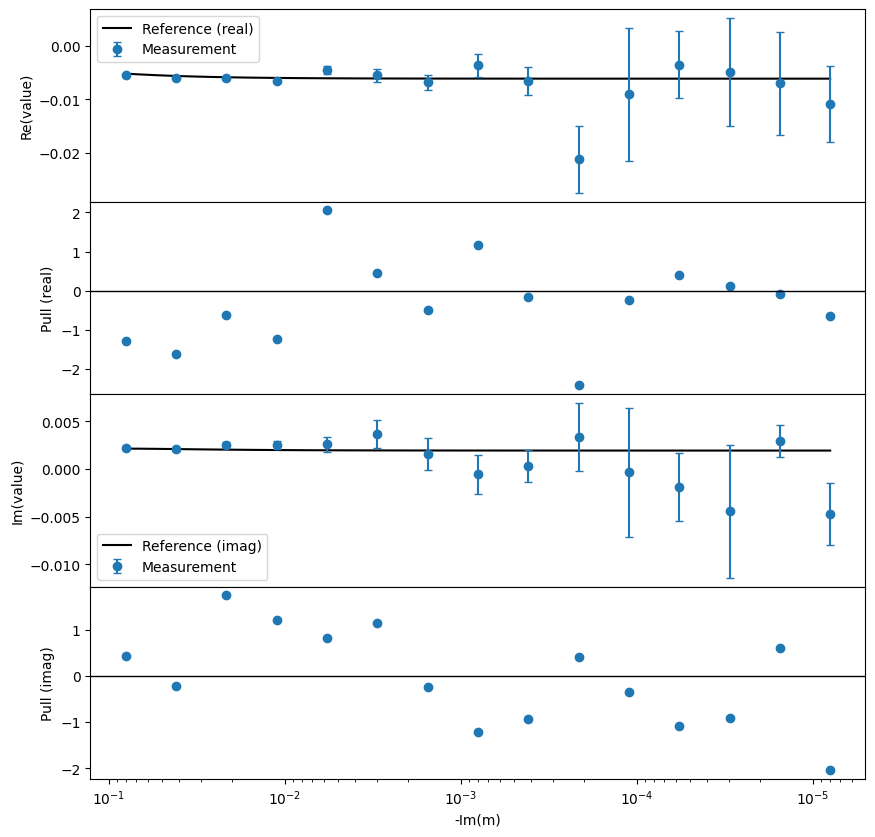

In [37]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.show()

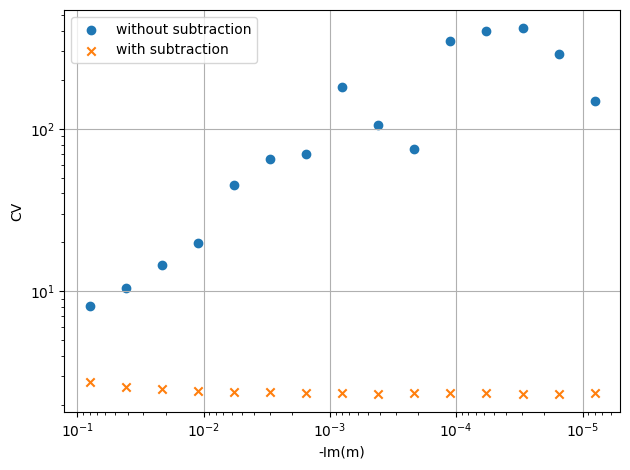

In [38]:
plt.scatter(-sample_masses.imag, [r.cv() for r in unsub_res], label = 'without subtraction', marker='o')
plt.scatter(-sample_masses.imag, [r.cv() for r in global_check_res],  label = 'with subtraction', marker='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('-Im(m)')
plt.ylabel('CV')
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../images/cv_mass_reg.png", dpi=300)
plt.show()

In [39]:
sample_masses = np.linspace(0.2,2,15)
ref_masses = np.linspace(0.2,2,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 1e10
per_sample_check = integrate_over_masses(sample_masses, tie)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

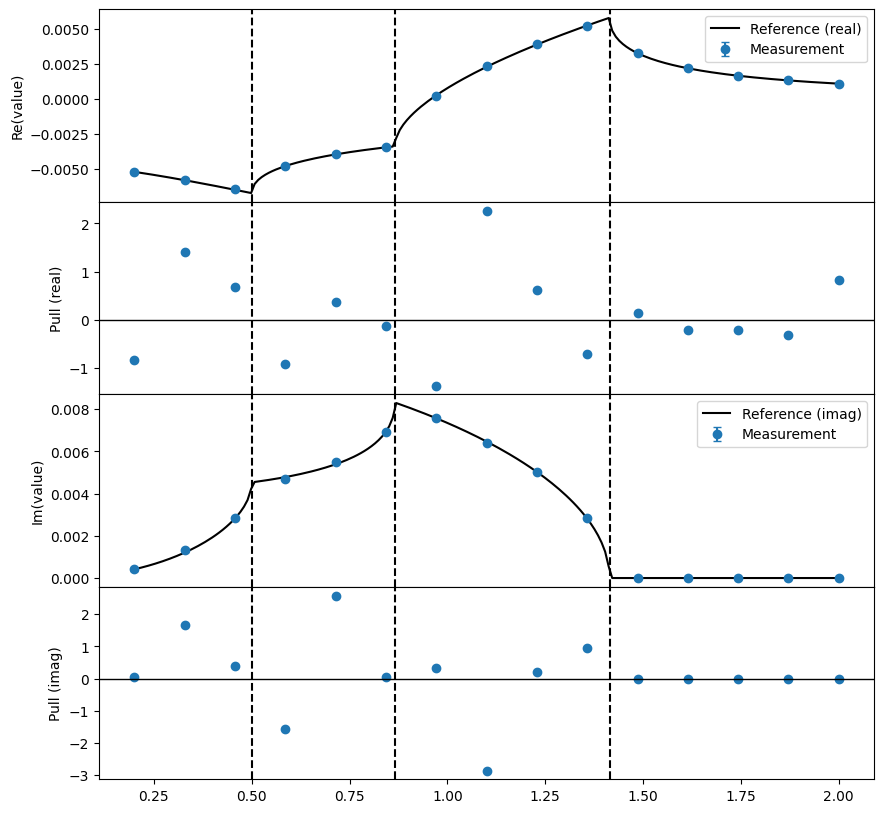

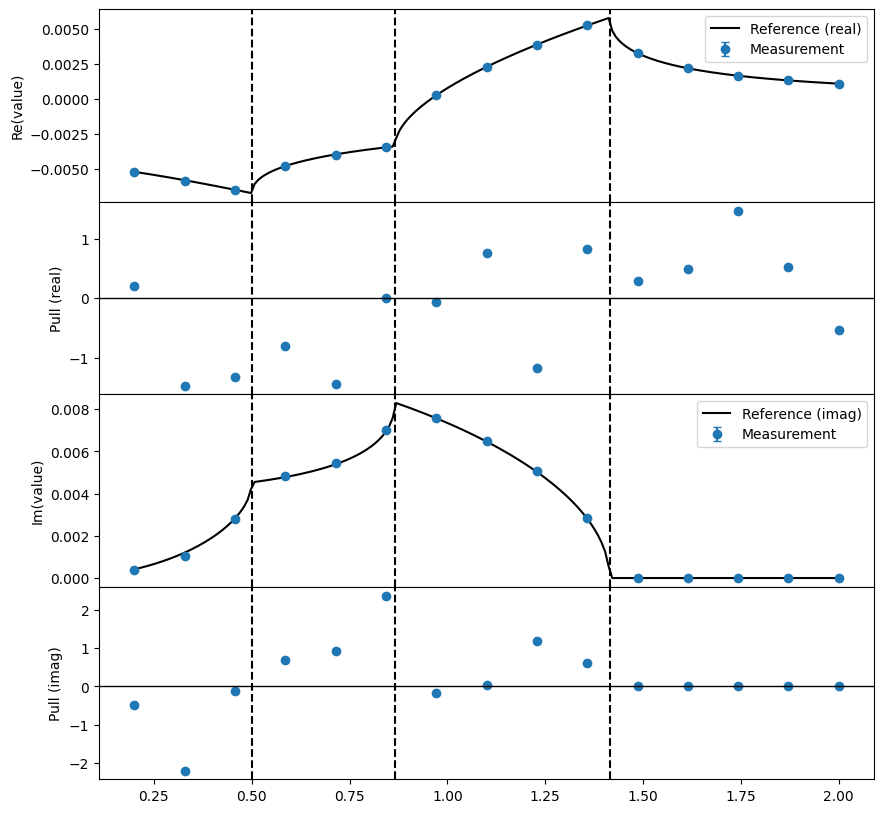

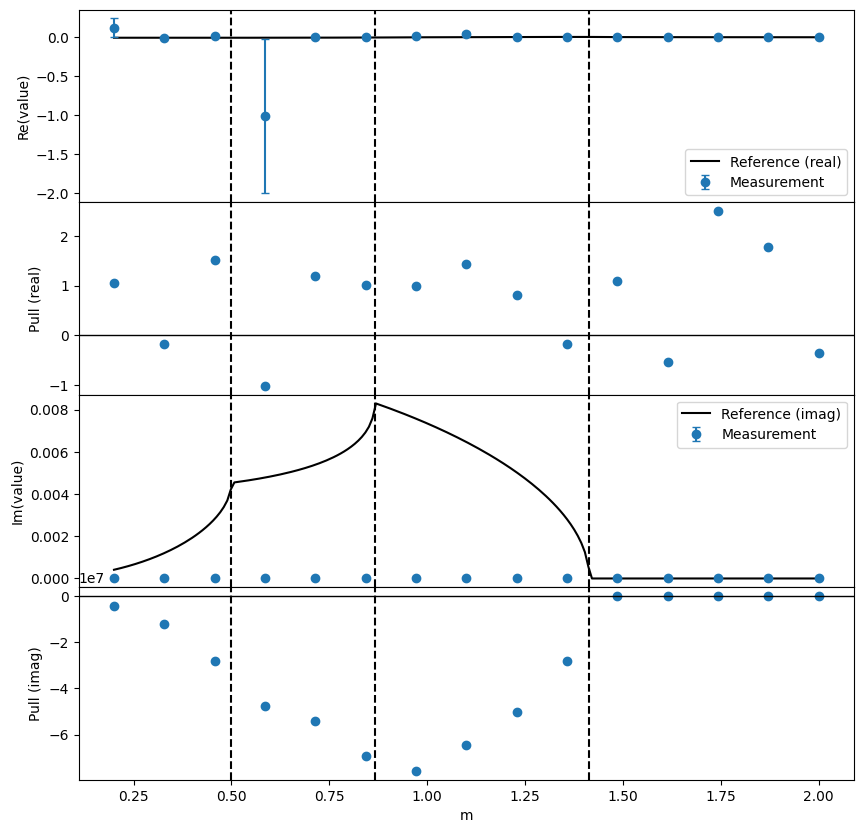

In [40]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
fig.get_axes()[-1].set_xlabel('m')
plt.show()

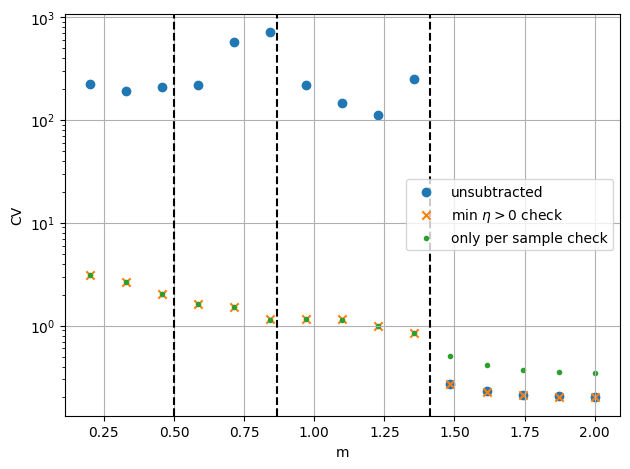

In [41]:
plt.scatter(sample_masses, [r.cv() for r in unsub_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.cv() for r in global_check_res], label = 'min $\\eta > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.cv() for r in per_sample_check], label = 'only per sample check', marker = '.')
plt.yscale('log')
for m in threshold_masses:
    plt.axvline(m, ls = "--", c = "black")
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.tight_layout()

plt.savefig("../images/cv_threshold_masses.png", dpi=300)
plt.show()


In [42]:
sample_masses = np.linspace(np.sqrt(2)-0.00001,np.sqrt(2)+0.00001,15)
ref_masses = np.linspace(np.sqrt(2)-0.00001,np.sqrt(2)+0.00001,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
rng = RandomNumberGenerator(0,0)
global_check_res = integrate_over_masses(sample_masses, tie, epochs = 100, steps = 2000)
ctx.max_eta_min = 1e15
rng = RandomNumberGenerator(0,0)
per_sample_check = integrate_over_masses(sample_masses, tie, epochs=100, steps = 2000)


ctx.only_unsubtracted()
rng = RandomNumberGenerator(0,0)
unsub_res = integrate_over_masses(sample_masses, tie, epochs = 100, steps = 2000)

ref = reference_over_masses(ref_masses)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

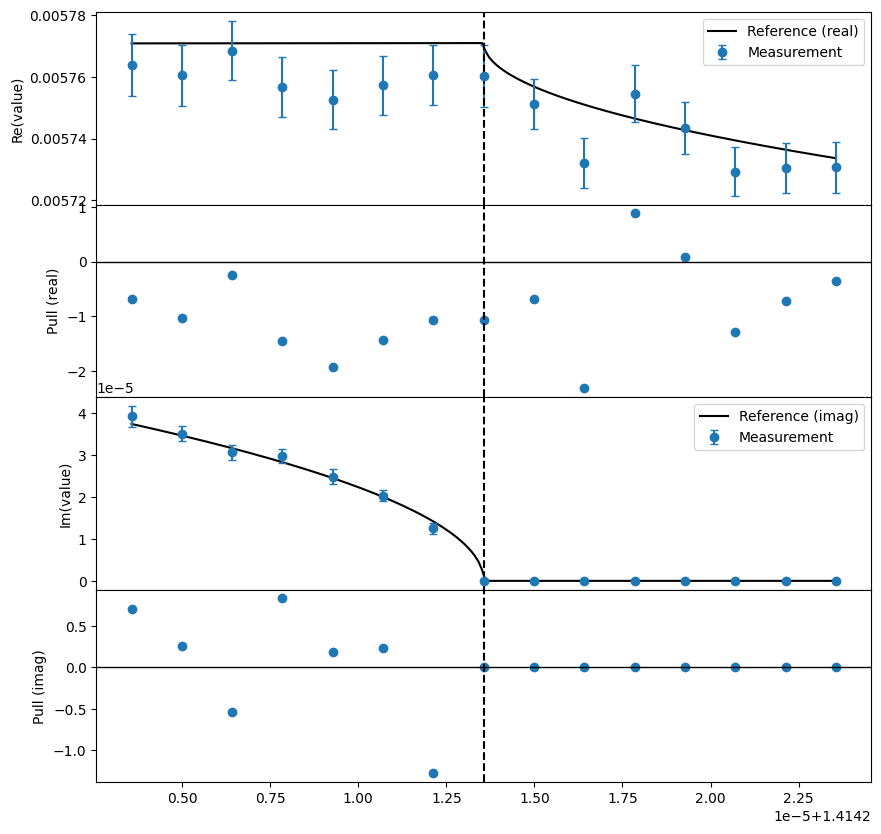

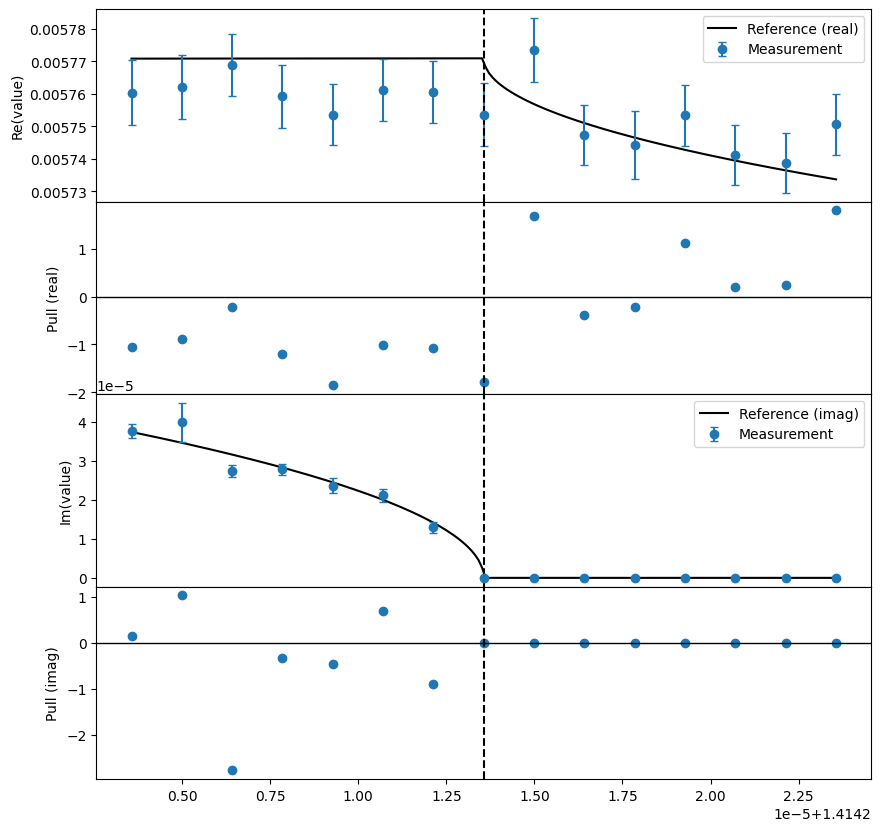

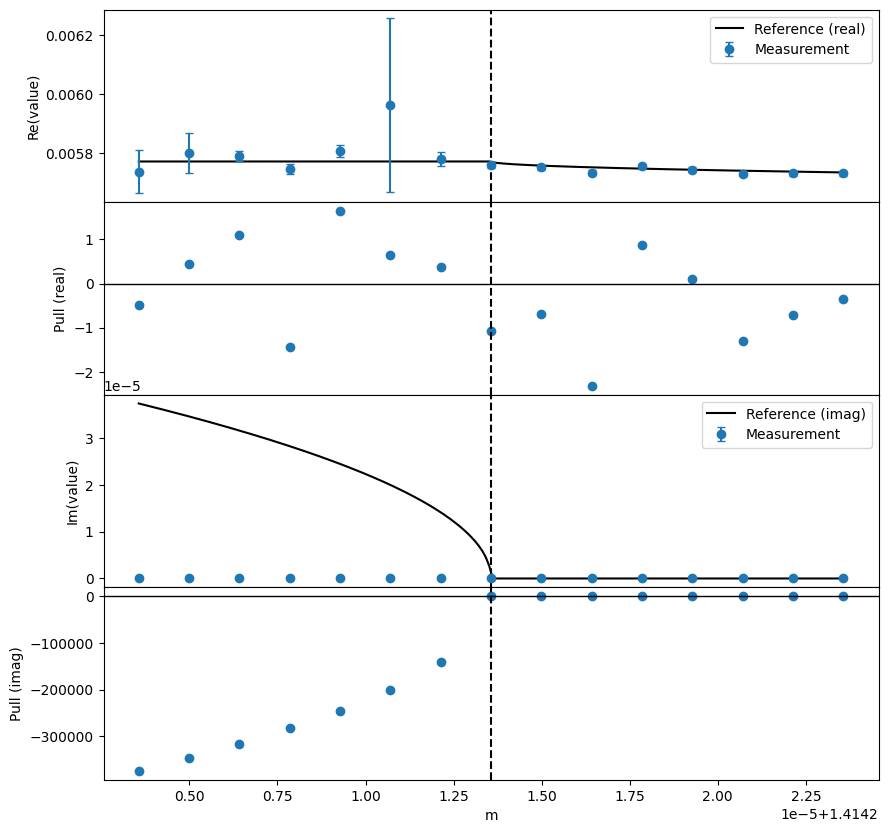

In [43]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
fig.get_axes()[-1].set_xlabel('m')
plt.show()

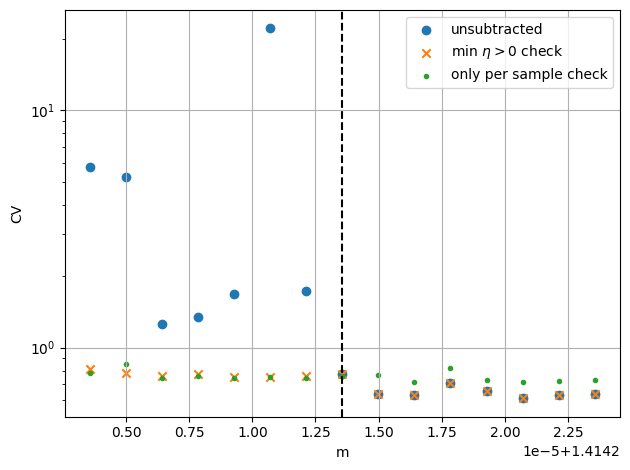

In [44]:
plt.scatter(sample_masses, [r.cv() for r in unsub_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.cv() for r in global_check_res], label = 'min $\\eta > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.cv() for r in per_sample_check], label = 'only per sample check', marker = '.')
plt.yscale('log')
plt.axvline(threshold_masses[2], ls = "--", c = "black")
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.tight_layout()

plt.savefig("../images/cv_threshold_masses.png", dpi=300)
plt.show()
